# Graph Neural Network — Graph Transformer

* 2-layer Graph Transformer using multi-head attention (TransformerConv)  
* Node classification on the Cora citation network  
* PyTorch + PyTorch Geometric

## Key difference from a plain GCN

| | GCN | Graph Transformer |
|---|---|---|
| Aggregation weights | Fixed (degree normalisation) | Learned (attention scores) |
| Skip connections | No | Yes (`beta=True`) |
| Normalisation | None | BatchNorm after layer 1 |
| Multi-head | No | Yes (`heads=4`) |
| Optimiser | Adam | AdamW + cosine LR |

TransformerConv computes **content-aware** attention weights:

$$\alpha_{ij} = \text{softmax}_j\!\left(\frac{(x_i W_Q)(x_j W_K)^\top}{\sqrt{d_k}}\right)$$

$$h_i = \sum_j \alpha_{ij} \cdot (x_j W_V)$$

This lets each node selectively attend to the most relevant neighbours, rather than averaging all of them equally.

## 1. Install Dependencies

In [2]:
# Run this cell once if packages are not already installed
# !pip install torch torch_geometric
# !pip install scipy

Installs PyTorch, PyTorch Geometric (the GNN framework), and SciPy (required by some PYG sparse utilities). Only needs to run once per environment.

## 2. Imports

In [2]:
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import TransformerConv, BatchNorm

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

C:\Users\jenny.liu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version : 2.11.0+cpu
CUDA available  : False


`TransformerConv` is the attention-based message-passing layer; `BatchNorm` stabilises training by normaliszing activations across the node dimension after layer 1. The version printout confirms GPU availability before loading data.

## 3. Load Dataset

**Cora** is a standard GNN benchmark. Each node is a scientific paper with a bag-of-words feature vector, and edges represent citations. The task is to classify each paper into one of 7 categories.

In [19]:
dataset = Planetoid(root="data/Cora", name="Cora", transform=NormalizeFeatures())
data    = dataset[0]   # single graph object

print(f"Nodes     : {data.num_nodes}")
print(f"Edges     : {data.num_edges}")
print(f"Features  : {data.num_node_features}")
print(f"Classes   : {dataset.num_classes}")
print(f"Train / Val / Test masks: "
      f"{data.train_mask.sum()} / {data.val_mask.sum()} / {data.test_mask.sum()}")

Nodes     : 2708
Edges     : 10556
Features  : 1433
Classes   : 7
Train / Val / Test masks: 140 / 500 / 1000


`NormalizeFeatures` row-normalizes each node’s bag-of-words vector so all features are on the same scale. The split is very small (140 training nodes for 2,708 total), making the task intentionally challenging and a good stress-test for the model’s generalisation.

## 4. Define the Graph Transformer Model

In [25]:
class GraphTransformer(nn.Module):
    """
    Two-layer Graph Transformer.

    Layer 1: TransformerConv (multi-head, concat)  →  BatchNorm  →  ELU  →  Dropout
    Layer 2: TransformerConv (single-head, no concat)  →  log-softmax

    beta=True adds a skip connection via a learned gate:
        h_i = gate * h_i_new + (1 - gate) * h_i_old
    mirroring residual connections in standard Transformers.
    """

    def __init__(
        self,
        in_channels: int,
        hidden_channels: int,
        out_channels: int,
        heads: int = 4,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.dropout = dropout

        # Layer 1 — multi-head attention; output dim = hidden_channels * heads
        self.conv1 = TransformerConv(
            in_channels,
            hidden_channels,
            heads=heads,
            dropout=dropout,
            beta=True,       # learned skip / residual gate
        )
        self.norm1 = BatchNorm(hidden_channels * heads)

        # Layer 2 — single-head attention; output dim = out_channels
        self.conv2 = TransformerConv(
            hidden_channels * heads,
            out_channels,
            heads=1,
            concat=False,    # average over heads instead of concatenating
            dropout=dropout,
            beta=True,
        )

    def forward(self, x, edge_index):
        # ── Layer 1 ──────────────────────────────────────────────────
        x = self.conv1(x, edge_index)           # (N, hidden * heads)
        x = self.norm1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # ── Layer 2 ──────────────────────────────────────────────────
        x = self.conv2(x, edge_index)           # (N, num_classes)
        return F.log_softmax(x, dim=1)

Layer 1 concatenates outputs from 4 attention heads, expanding the representation to `hidden * heads` dims. Layer 2 collapses back to `num_classes` with a single head (`concat=False`). `beta=True` adds a learned residual gate at both layers, letting the model blend the new aggregated representation with the node’s own previous embedding.

## 5. Initialise Model, Define Optimizer, and Move to Device

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data   = data.to(device)

model = GraphTransformer(
    in_channels=dataset.num_node_features,
    hidden_channels=32,     # 128-dim 
    out_channels=dataset.num_classes,
    heads=4,
    dropout=0.3,
).to(device)

# AdamW + cosine annealing works well with attention-based models
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

GraphTransformer(
  (conv1): TransformerConv(1433, 32, heads=4)
  (norm1): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): TransformerConv(128, 7, heads=1)
)

Total parameters: 738,481


AdamW’s (Adam with decoupled Weight decay) decoupled weight decay is better suited to attention models than plain Adam. Cosine annealing smoothly reduces the learning rate from `lr` to ~0 over 200 epochs, avoiding sharp loss spikes late in training. `hidden_channels=32` with 4 heads gives a 128-dim intermediate representation.

## 6. Training and Evaluation Functions

In [27]:
def train():
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    scheduler.step()
    return loss.item()


@torch.no_grad()
def evaluate():
    model.eval()
    pred = model(data.x, data.edge_index).argmax(dim=1)
    results = {}
    for split, mask in [("train", data.train_mask),
                        ("val",   data.val_mask),
                        ("test",  data.test_mask)]:
        correct = (pred[mask] == data.y[mask]).sum()
        results[split] = correct.item() / mask.sum().item()
    return results

`train` runs a single full-graph forward pass (transductive setting — all nodes are visible, only train-mask nodes contribute to the loss). `evaluate` wraps inference in `@torch.no_grad()` to skip gradient tracking and reports accuracy for each split without rerunning the model three times.

## 7. Run Training Loop

In [28]:
history = {"loss": [], "train": [], "val": [], "test": []}

for epoch in range(1, 201):
    loss = train()
    acc  = evaluate()
    history["loss"].append(loss)
    history["train"].append(acc["train"])
    history["val"].append(acc["val"])
    history["test"].append(acc["test"])

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d}  loss={loss:.4f}  "
              f"train={acc['train']:.3f}  val={acc['val']:.3f}  test={acc['test']:.3f}")

print(f"\nFinal test accuracy: {history['test'][-1]:.4f}")

Epoch 020  loss=0.3728  train=0.629  val=0.418  test=0.422
Epoch 040  loss=0.0773  train=1.000  val=0.690  test=0.703
Epoch 060  loss=0.0386  train=1.000  val=0.762  test=0.748
Epoch 080  loss=0.0244  train=1.000  val=0.728  test=0.732
Epoch 100  loss=0.0178  train=1.000  val=0.696  test=0.718
Epoch 120  loss=0.0165  train=1.000  val=0.682  test=0.701
Epoch 140  loss=0.0108  train=1.000  val=0.676  test=0.690
Epoch 160  loss=0.0077  train=1.000  val=0.676  test=0.689
Epoch 180  loss=0.0103  train=1.000  val=0.678  test=0.689
Epoch 200  loss=0.0109  train=1.000  val=0.680  test=0.688

Final test accuracy: 0.6880


History is stored for all four metrics so the curves can be plotted smoothly. Progress is printed every 20 epochs as verification.

## 8. Plot Training Curves

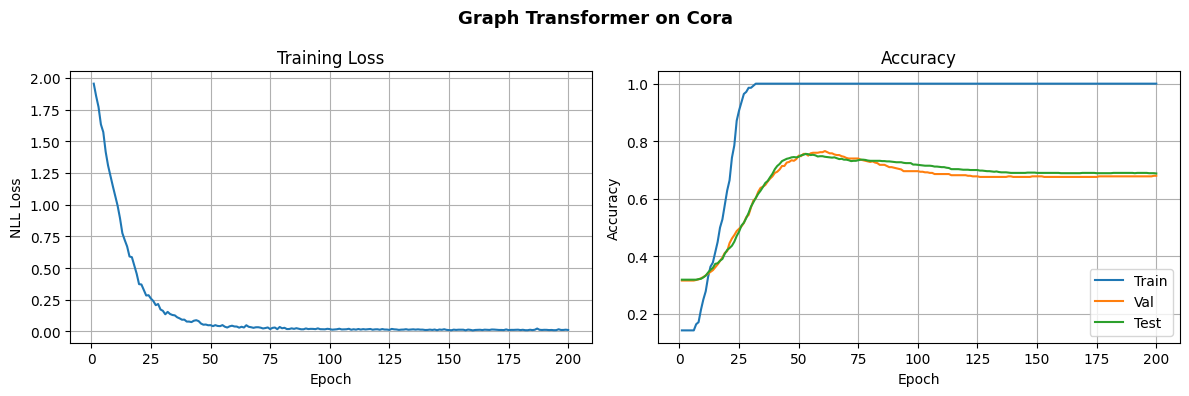

In [29]:
import matplotlib.pyplot as plt

epochs = range(1, 201)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["loss"])
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("NLL Loss")
ax1.grid(True)

ax2.plot(epochs, history["train"], label="Train")
ax2.plot(epochs, history["val"],   label="Val")
ax2.plot(epochs, history["test"],  label="Test")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.suptitle("Graph Transformer on Cora", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The left panel shows whether the loss is decreasing smoothly (cosine LR should prevent plateaus). The right panel reveals overfitting: if the train curve climbs while val/test flatten, dropout or weight decay should be increased. Healthy runs show train ≈ val ≈ test after epoch ~100.